### Estudo das respostas de outros modelos de llms slr1

Vamos simular as variabilidade das respostas das llms, olhando para as soluções da google

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import google.generativeai as genai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [4]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


In [5]:

# Configurar a chave de API
genai.configure(api_key=os.getenv("GOOGLE_API_KEY_LLMS_PROF_DANILO"))

In [6]:
# Criar um modelo Gemini
model = genai.GenerativeModel("gemini-pro")

# Fazer uma pergunta
pergunta = "Qual a capital do Brasil?"
response = model.generate_content(pergunta)

# Exibir a resposta
print(response.text)

NotFound: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

# LLMs da Google
-----

### Leitura dos arquivos

In [7]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning\n based cognitive skills cal...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


In [8]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [9]:
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


#### Limpeza dos casos em que não conseguimos extrair as informações


In [10]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

(126, 8)

In [11]:
print("Shape antes da limpeza: "+str(df_slr1.shape))
print("Shape depois da limpeza"+str(df_slr1_clear.shape))

Shape antes da limpeza: (134, 8)
Shape depois da limpeza(126, 8)


In [12]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


### Seleção usando o Gemini

In [13]:
# Liste os modelos disponíveis
modelos = genai.list_models()

# Exiba os nomes dos modelos
for modelo in modelos:
    print(modelo.name)

models/embedding-gecko-001
models/gemini-1.5-pro-latest
models/gemini-1.5-pro-002
models/gemini-1.5-pro
models/gemini-1.5-flash-latest
models/gemini-1.5-flash
models/gemini-1.5-flash-002
models/gemini-1.5-flash-8b
models/gemini-1.5-flash-8b-001
models/gemini-1.5-flash-8b-latest
models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-preview-image-generation
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/ge

In [14]:
def process_selection_with_gemini(model_gemini, title,abstract, keywords, inclusion_criteria_question):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo Gemini.
    """
    
    # Criar um modelo Gemini-Pro
    model = genai.GenerativeModel(model_gemini)

    # Construção do prompt
    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considerando o título, resumo e palavras-chave de um estudo primário.

    Usando uma escala Likert de 1 a 7 (1 - Discordo totalmente, 2 - Discordo, 3 - Discordo parcialmente,
    4 - Neutro, 5 - Concordo parcialmente, 6 - Concordo, e 7 - Concordo totalmente), avalie sua concordância 
    com a seguinte pergunta:  

    "{inclusion_criteria_question}"

    Sobre o artigo:  
    **Título:** {title}  
    **Resumo:** {abstract}  
    **Palavras-chave:** {keywords}

    Apenas retorne um número de 1 a 7, sem nenhuma explicação adicional.
    """

    # Fazer a chamada à API do Gemini
    response = model.generate_content(prompt)

    try:
        resposta = int(response.text.strip())  # Converte a resposta para número inteiro
        return resposta
    except ValueError:
        print("Erro ao processar a resposta:", response.text)
        return None


In [15]:
model_gemini = "gemini-1.5-flash" #
title = df_slr1_clear["title"].iloc[0]
abstract = df_slr1_clear["abstract"].iloc[0]
keywords = df_slr1_clear["keywords"].iloc[0]
inclusion_criteria_question = "It is a secondary study (Systematic Review, Mapping Study, Rapid Review, or Systematic Mapping)?"

In [16]:
resposta_teste = process_selection_with_gemini(model_gemini = model_gemini,
                                            title = title,
                                            abstract = abstract,
                                            keywords = keywords,
                                            inclusion_criteria_question= inclusion_criteria_question)
resposta_teste

7

In [17]:
def repeat_selection_with_gemini(df, model_gemini, inclusion_criteria_question,n_interactions,name_ic):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_gemini+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp__slr1_{model_gemini}_{name_ic}_iter_{i}_v2.xlsx"
        df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(15)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [18]:
# paramentros globais
n_interactions = 5  # fixemos em 10 vezes devido ao custo

#### Modelo: "gemini-1.5-flash"

In [19]:
df_gemini_15_flash  = df_slr1_clear.copy()
df_gemini_15_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [20]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" #  ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gemini_15_flash = repeat_selection_with_gemini(df = df_gemini_15_flash,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic)

100%|██████████| 126/126 [00:49<00:00,  2.56it/s]


In [21]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gemini_15_flash = repeat_selection_with_gemini(df = df_gemini_15_flash,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic)

100%|██████████| 126/126 [00:49<00:00,  2.56it/s]


In [22]:
df_gemini_15_flash.head()

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,gemini-1.5-flash_IC1_2,gemini-1.5-flash_IC1_3,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,5,5,6,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,6,6,6,6,1,1,1,2,1
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,3,3,3,3,3
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,3,3,3,3,3
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado,1,1,1,1,1,1,1,1,1,1


#### Modelo "gemini-2.5-flash"

In [30]:
df_gemini_pro  = df_slr1_clear.copy()
df_gemini_pro.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [31]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gemini_pro = repeat_selection_with_gemini(df = df_gemini_pro,
                                        model_gemini = model_gemini,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [10:51<00:00,  5.17s/it]


In [32]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence """
name_ic = "IC2"
df_gemini_pro = repeat_selection_with_gemini(df = df_gemini_pro,
                                        model_gemini = model_gemini,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [20:01<00:00,  9.54s/it]


### gemini-2.0-flash 

In [34]:
df_gemini_20_flash  = df_slr1_clear.copy()
df_gemini_20_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [35]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.0-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gemini_20_flash = repeat_selection_with_gemini(df = df_gemini_20_flash,
                                        model_gemini = model_gemini,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [01:11<00:00,  1.77it/s]


In [36]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.0-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gemini_20_flash = repeat_selection_with_gemini(df = df_gemini_20_flash,
                                        model_gemini = model_gemini,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [01:12<00:00,  1.74it/s]


### Gravação

#### gemini 1.5 - flash

In [24]:
df_gemini_15_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,gemini-1.5-flash_IC1_2,gemini-1.5-flash_IC1_3,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,5,5,6,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,6,6,6,6,1,1,1,2,1


In [25]:
# grava os resultados
df_gemini_15_flash.to_excel("/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1_v2.xlsx", index=False)
df_gemini_15_flash.to_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1_v2.csv", encoding='utf-8', index=False)

#### gemini gemini-2.5-flash-preview-04-17

In [33]:
df_gemini_pro.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-2.5-flash_IC1_0,gemini-2.5-flash_IC1_1,gemini-2.5-flash_IC1_2,gemini-2.5-flash_IC1_3,gemini-2.5-flash_IC1_4,gemini-2.5-flash_IC2_0,gemini-2.5-flash_IC2_1,gemini-2.5-flash_IC2_2,gemini-2.5-flash_IC2_3,gemini-2.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,7,7,7,7,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,1,1,2,1


In [37]:
# grava os resultados
df_gemini_pro.to_excel("/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr1_v2.xlsx", index=False)
df_gemini_pro.to_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr1_v2.csv", encoding='utf-8', index=False)

### gemini 2.0 - flash

In [38]:
df_gemini_20_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-2.0-flash_IC1_0,gemini-2.0-flash_IC1_1,gemini-2.0-flash_IC1_2,gemini-2.0-flash_IC1_3,gemini-2.0-flash_IC1_4,gemini-2.0-flash_IC2_0,gemini-2.0-flash_IC2_1,gemini-2.0-flash_IC2_2,gemini-2.0-flash_IC2_3,gemini-2.0-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,6,1,1,1,1,2,3,3,3,3


In [39]:
# grava os resultados
df_gemini_20_flash.to_excel("/data/codigos/dados/resultados/reproducao_resultados_gemini_20_flash_slr1_v2.xlsx", index=False)
df_gemini_20_flash.to_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_20_flash_slr1_v2.csv", encoding='utf-8', index=False)

## Analise dos resultados

### Leitura dos resultados processados

In [40]:
df_gemini_15_flash = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1_v2.csv",encoding='utf-8')
df_gemini_15_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,gemini-1.5-flash_IC1_2,gemini-1.5-flash_IC1_3,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,5,5,6,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,6,6,6,6,1,1,1,2,1


In [41]:
df_gemini_pro = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr1_v2.csv",encoding='utf-8')
df_gemini_pro.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-2.5-flash_IC1_0,gemini-2.5-flash_IC1_1,gemini-2.5-flash_IC1_2,gemini-2.5-flash_IC1_3,gemini-2.5-flash_IC1_4,gemini-2.5-flash_IC2_0,gemini-2.5-flash_IC2_1,gemini-2.5-flash_IC2_2,gemini-2.5-flash_IC2_3,gemini-2.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,7,7,7,7,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,1,1,2,1


In [42]:
df_gemini_20_flash = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_20_flash_slr1_v2.csv",encoding='utf-8')
df_gemini_20_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-2.0-flash_IC1_0,gemini-2.0-flash_IC1_1,gemini-2.0-flash_IC1_2,gemini-2.0-flash_IC1_3,gemini-2.0-flash_IC1_4,gemini-2.0-flash_IC2_0,gemini-2.0-flash_IC2_1,gemini-2.0-flash_IC2_2,gemini-2.0-flash_IC2_3,gemini-2.0-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,6,1,1,1,1,2,3,3,3,3


In [43]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [44]:
df_gemini_15_flash = pd.merge(left=df_gemini_15_flash, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gemini_15_flash.shape


(126, 21)

In [45]:
df_gemini_pro = pd.merge(left=df_gemini_pro, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gemini_pro.shape

(126, 21)

In [46]:
df_gemini_20_flash = pd.merge(left=df_gemini_20_flash, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gemini_20_flash.shape

(126, 21)

In [47]:
print("df_gemini_15_flash: "+str(df_gemini_15_flash.shape))
print("df_gemini_pro: "+str(df_gemini_pro.shape))
print("df_gemini_20_flash: "+str(df_gemini_20_flash.shape))
print("df_slr1_autores: "+str(df_slr1_autores.shape))


df_gemini_15_flash: (126, 21)
df_gemini_pro: (126, 21)
df_gemini_20_flash: (126, 21)
df_slr1_autores: (135, 7)


### Geração dos resultados das llms e padronizacao dos campos

In [48]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [49]:
df_gemini_15_flash = convert_benchmark(df_gemini_15_flash,"Benchmark")

In [50]:
df_gemini_pro = convert_benchmark(df_gemini_pro,"Benchmark")

In [51]:
df_gemini_20_flash = convert_benchmark(df_gemini_20_flash,"Benchmark")

In [52]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [53]:
df_gemini_15_flash.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,...,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,...,7,6,5,5,6,5,7.0,6.0,I,1


In [54]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [55]:
n_interactions = 5

In [56]:

model_gpt = "gemini-1.5-flash"
df_gemini_15_flash = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gemini_15_flash)

In [57]:
df_gemini_15_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,...,gemini-1.5-flash_IC2_4,IC1,IC2,Benchmark,result_bench,gemini-1.5-flash_0,gemini-1.5-flash_1,gemini-1.5-flash_2,gemini-1.5-flash_3,gemini-1.5-flash_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,...,5,7.0,6.0,I,1,1,1,1,1,1
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,6,...,1,7.0,4.0,E,0,0,0,0,0,0


In [58]:

model_gpt = "gemini-2.5-flash"
df_gemini_pro = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gemini_pro)

In [59]:

model_gpt = "gemini-2.0-flash"
df_gemini_20_flash = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gemini_20_flash)

### Analises de performance

In [60]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [61]:
model_gpt = "gemini-1.5-flash"
df_result_gemini_15_flash = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gemini_15_flash, 
                                    col_benchmark='result_bench')
df_result_gemini_15_flash

,Model_Iteration,Accuracy
0,gemini-1.5-flash_0,0.825397
1,gemini-1.5-flash_1,0.809524
2,gemini-1.5-flash_2,0.817460
3,gemini-1.5-flash_3,0.809524
4,gemini-1.5-flash_4,0.817460


In [62]:
model_gpt = "gemini-2.5-flash"
df_result_gemini_pro = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gemini_pro, 
                                    col_benchmark='result_bench')
df_result_gemini_pro

,Model_Iteration,Accuracy
0,gemini-2.5-flash_0,0.714286
1,gemini-2.5-flash_1,0.746032
2,gemini-2.5-flash_2,0.761905
3,gemini-2.5-flash_3,0.769841
4,gemini-2.5-flash_4,0.738095


In [63]:
model_gpt = "gemini-2.0-flash"
df_result_gemini_20_flash = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gemini_20_flash, 
                                    col_benchmark='result_bench')
df_result_gemini_20_flash

,Model_Iteration,Accuracy
0,gemini-2.0-flash_0,0.738095
1,gemini-2.0-flash_1,0.722222
2,gemini-2.0-flash_2,0.730159
3,gemini-2.0-flash_3,0.738095
4,gemini-2.0-flash_4,0.722222


In [64]:
def graph_scatter_plot(df,col_values,col_name_models,title_graph,xlabel,ylabel,ylim_flag,ylim):
    # Supondo que df seja o dataframe com as colunas "Model_Iteration" e "Accuracy"
    # Calcular a média e o desvio padrão da acurácia
    mean_accuracy = df[col_values].mean()
    std_accuracy = df[col_values].std()

    # Configurar o tamanho da figura
    plt.figure(figsize=(12, 6))

    # Criar o scatterplot
    plt.scatter(df[col_name_models], df[col_values], color='royalblue', label='Accuracy')

    # Adicionar linhas horizontais para a média e os limites inferior e superior
    plt.axhline(y=mean_accuracy, color='darkblue', linestyle='-', label='Mean Accuracy')
    plt.axhline(y=mean_accuracy - std_accuracy, color='cornflowerblue', linestyle='--', label='Mean - Std Dev')
    plt.axhline(y=mean_accuracy + std_accuracy, color='cornflowerblue', linestyle='--', label='Mean + Std Dev')

    # Adicionar título e nomes nos eixos
    plt.title(title_graph)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Adicionar legenda
    plt.legend()

    # limite
    if ylim_flag:
        plt.ylim(ylim)

    # Rotacionar os rótulos do eixo x para melhor visualização
    plt.xticks(rotation=45)

    # Exibir o gráfico
    plt.tight_layout()
    
    # Remover bordas desnecessárias
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()



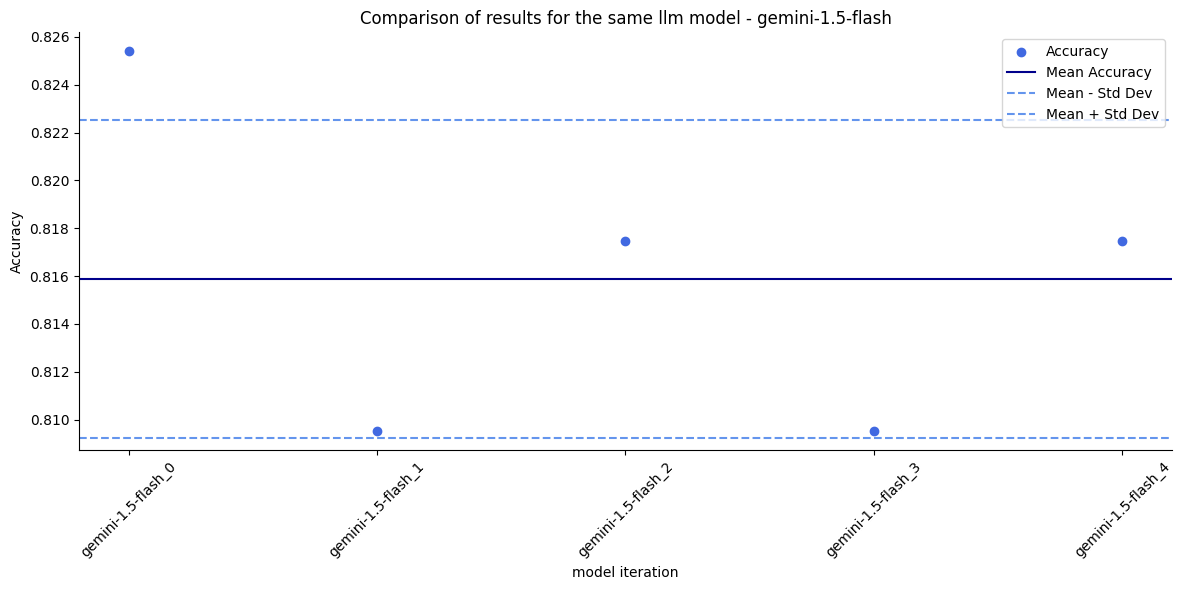

In [65]:
graph_scatter_plot(df = df_result_gemini_15_flash,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - gemini-1.5-flash",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

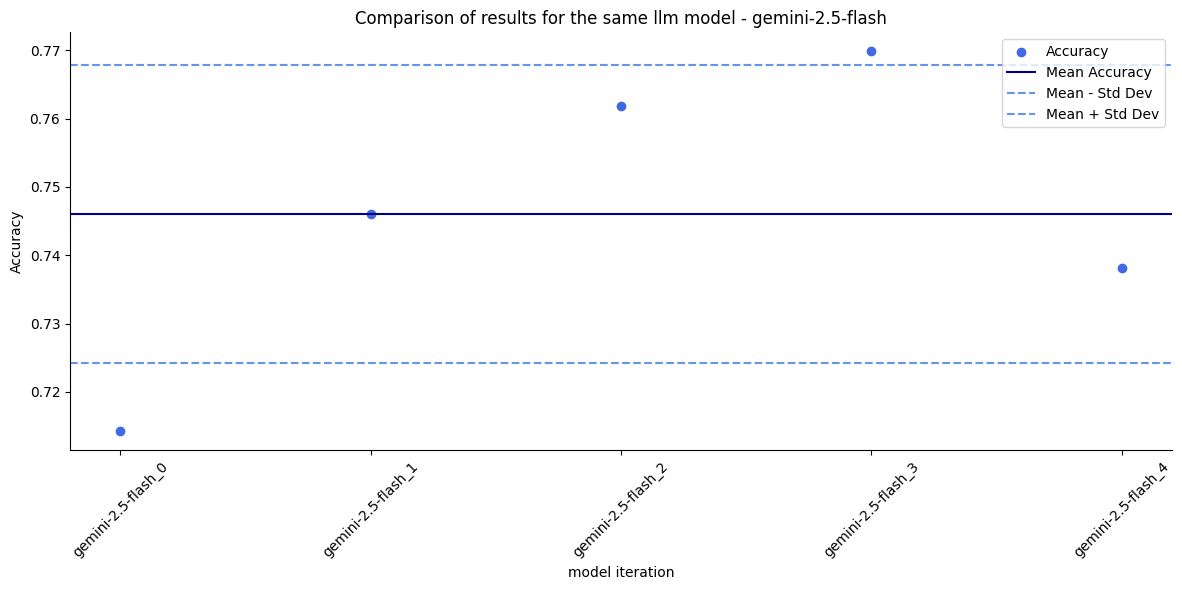

In [66]:
graph_scatter_plot(df = df_result_gemini_pro,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - gemini-2.5-flash",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

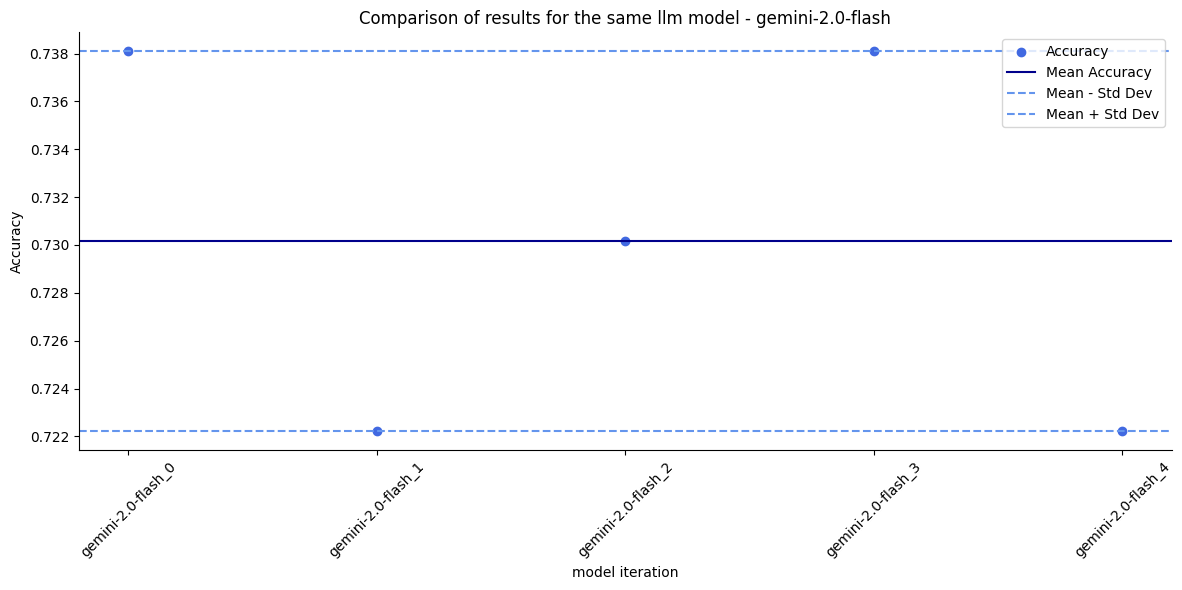

In [67]:
graph_scatter_plot(df = df_result_gemini_20_flash,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - gemini-2.0-flash",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

Nota-se que para modelos mais avançados a variabilidade é menor, indicando estabilização mais rápida.

In [68]:
### Grava os resultados finais
df_result_gemini_15_flash.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_gemini_15_flash_final_slr1_v2.xlsx", index=False)
df_result_gemini_15_flash.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_gemini_15_flash_final_slr1_v2.csv", encoding='utf-8', index=False)

df_result_gemini_pro.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_gemini_pro_final_slr1_v2.xlsx", index=False)
df_result_gemini_pro.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_gemini_pro_final_slr1_v2.csv", encoding='utf-8', index=False)

df_result_gemini_20_flash.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_gemini_20_flash_final_slr1_v2.xlsx", index=False)
df_result_gemini_20_flash.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_gemini_20_flash_final_slr1_v2.csv", encoding='utf-8', index=False)

### Comparativo Geral

In [72]:
df_result_gemini_15_flash["iteration"] = df_result_gemini_15_flash["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gemini_15_flash["model"] = "gemini-1.5-flash"

df_result_gemini_pro["iteration"] = df_result_gemini_pro["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gemini_pro["model"] = "gemini-2.5-flash"

df_result_gemini_20_flash["iteration"] = df_result_gemini_20_flash["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gemini_20_flash["model"] = "gemini-2.0-flash"

In [73]:
# concatena os dataframes
df_results = pd.concat([df_result_gemini_15_flash, 
                        df_result_gemini_pro, 
                        df_result_gemini_20_flash], ignore_index=True)
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,gemini-1.5-flash_0,0.825397,0,gemini-1.5-flash
1,gemini-1.5-flash_1,0.809524,1,gemini-1.5-flash


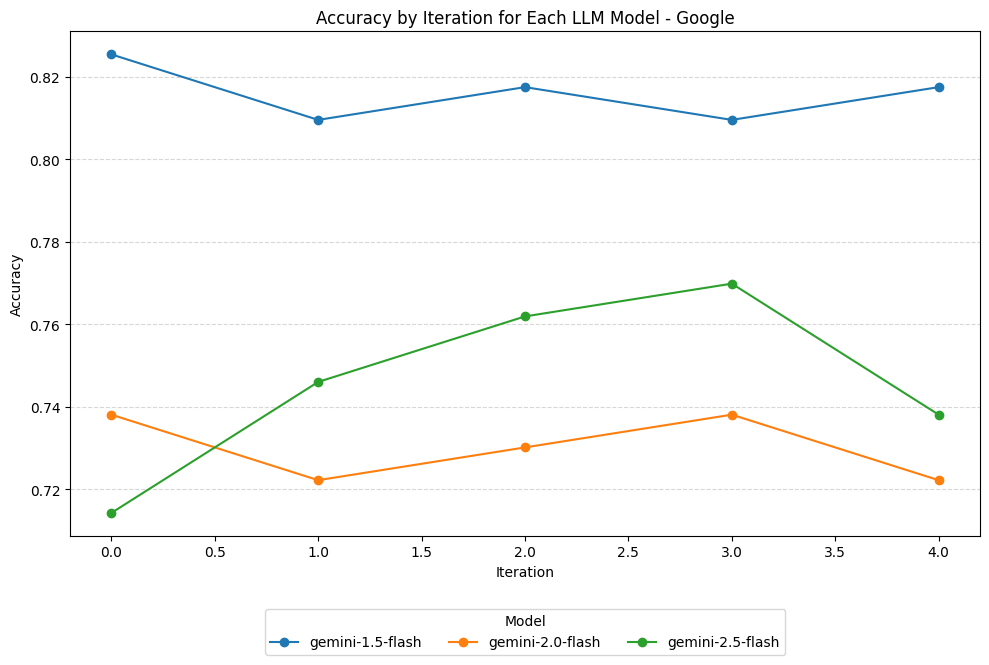

In [74]:
plt.figure(figsize=(10, 6))
for model_name, group in df_results.groupby("model"):
    plt.plot(group["iteration"], group["Accuracy"], marker='o', label=model_name)

plt.title("Accuracy by Iteration for Each LLM Model - Google")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(title="Model", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.show()
